
# Bias vs Variance with Multilayer Perceptron (MLP)

This notebook explains **bias**, **variance**, and the **bias-variance tradeoff** using a **Multilayer Perceptron (MLP)** on a nonlinear classification dataset.



## Introduction


Bias and variance are fundamental concepts in machine learning that help us understand the behavior of predictive models in relation to the underlying data they are trained on. These concepts are crucial for diagnosing the performance issues of a model, particularly in the context of overfitting and underfitting.

**Bias** refers to the error introduced by approximating a real-world problem, which may be complex, by a much simpler model. In other words, bias measures how far off, on average, a model's predictions are from the actual value. High bias can lead to underfitting, where the model is too simple to capture the underlying structure of the data. This results in poor performance on both the training data and unseen data.

**Variance**, on the other hand, refers to the error introduced by sensitivity to small fluctuations in the training set. High variance suggests that the model is so complex that it captures noise in the training data as if it were a real pattern, leading to overfitting. An overfitted model performs well on the training data but poorly on any unseen data because it fails to generalize from the specific examples it was trained on.

The relationship between bias and variance is tied to the model's complexity:

- **Low-complexity models** tend to have high bias and low variance because they make strong assumptions about the form of the underlying function that generates the data. Such models are prone to underfitting.
- **High-complexity models** tend to have low bias and high variance because they make fewer assumptions about the form of the underlying function. Such models can capture more complex patterns but are also more likely to capture noise as if it were a signal, leading to overfitting.

The **bias-variance tradeoff** is a central problem in supervised learning. Ideally, one wants to choose a model complexity that achieves a balance between bias and variance, minimizing total error. This balance is crucial for developing predictive models that generalize well from training data to unseen data.

Understanding the bias-variance tradeoff is essential for diagnosing and correcting the performance of machine learning models. It aids in selecting the right algorithm and in tuning the hyperparameters to optimize model performance. Techniques such as cross-validation, regularization, and ensemble methods are often used to manage bias and variance effectively, aiming to build models that neither overfit nor underfit the data.

We implemented following items in this notebook:
1. Build a nonlinear dataset
2. Train a **small MLP** (high bias / underfitting)
3. Train a **balanced MLP**
4. Train a **large MLP** (high variance / overfitting)
5. Compare **training vs test performance**
6. Visualize **decision boundaries**

The main idea:

- **High bias**: model is too simple, so it cannot capture the true pattern.
- **High variance**: model is too complex, so it memorizes training data and does not generalize well.
- **Good generalization**: model complexity is balanced.

---


In [1]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score



## 1. Create a nonlinear dataset

We use the **two moons** dataset because a linear model struggles on it, while an MLP can learn a curved boundary.


Training samples: 420
Test samples: 180


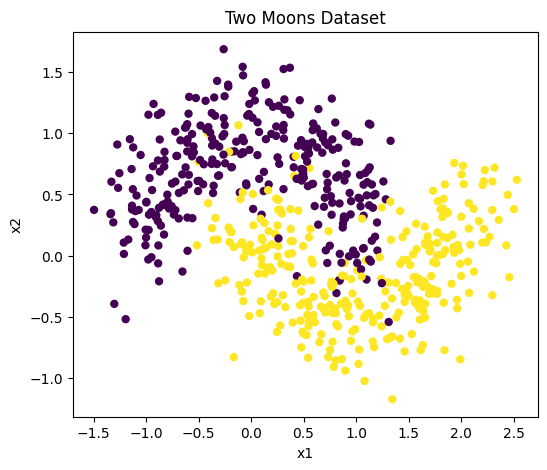

In [2]:

X, y = make_moons(n_samples=600, noise=0.25, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, s=25)
plt.title("Two Moons Dataset")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()



## Helper function: plot decision boundary


In [3]:

def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
    y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, zz, alpha=0.35)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=25, edgecolor="k")
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()


def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy : {test_acc:.4f}")
    return train_acc, test_acc



## 2. High bias example: a very small MLP

A tiny network has **limited capacity**.  
Even though the data is nonlinear, the model may learn an overly simple boundary.

This usually causes:

- training accuracy to stay relatively low
- test accuracy to also stay low
- underfitting

We call this **high bias**.


Small MLP (High Bias)
Train Accuracy: 0.8667
Test Accuracy : 0.8556


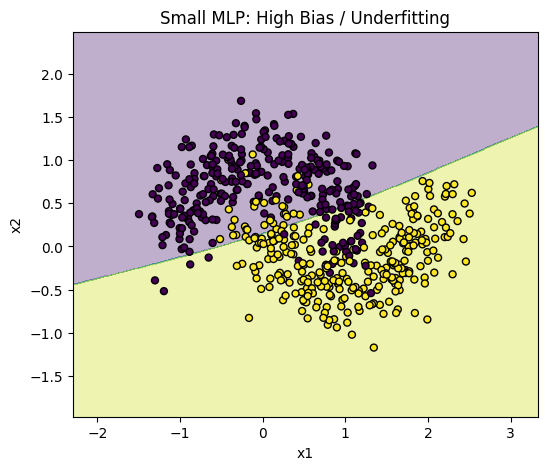

In [4]:

small_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(2,),
        activation="tanh",
        solver="adam",
        alpha=0.0001,
        max_iter=2000,
        random_state=42
    ))
])

small_train_acc, small_test_acc = evaluate_model(
    "Small MLP (High Bias)", small_mlp, X_train, y_train, X_test, y_test
)

plot_decision_boundary(small_mlp, X, y, "Small MLP: High Bias / Underfitting")



### Interpretation

If both training and test performance are not very good, the model is **too simple**.

This is the neural-network version of **underfitting**:
the model does not have enough flexibility to represent the true shape of the data.



## 3. Balanced model: moderate-size MLP

Now we increase model capacity just enough to learn the nonlinear pattern without making the model excessively complex.


Balanced MLP
Train Accuracy: 0.9524
Test Accuracy : 0.9389


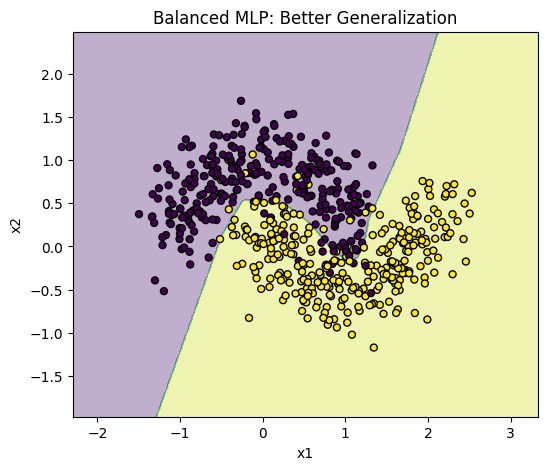

In [5]:

balanced_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(16, 8),
        activation="relu",
        solver="adam",
        alpha=0.001,
        max_iter=3000,
        random_state=42
    ))
])

balanced_train_acc, balanced_test_acc = evaluate_model(
    "Balanced MLP", balanced_mlp, X_train, y_train, X_test, y_test
)

plot_decision_boundary(balanced_mlp, X, y, "Balanced MLP: Better Generalization")



### Interpretation

Here the model is expressive enough to learn the curved decision boundary.

A good sign is:
- high training accuracy
- high test accuracy
- relatively small train-test gap

This is the region where **generalization** is strongest.



## 4. High variance example: a large MLP

Now we use a much bigger network.  
A highly flexible network can fit subtle details and even noise in the training set.

This often leads to:

- extremely high training accuracy
- noticeably worse test accuracy
- overfitting

We call this **high variance**.


Large MLP (High Variance)
Train Accuracy: 0.9500
Test Accuracy : 0.9278


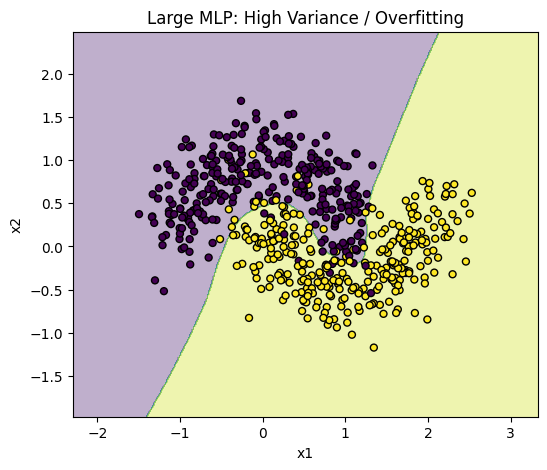

In [6]:

large_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(128, 128, 64, 32),
        activation="relu",
        solver="adam",
        alpha=1e-6,
        max_iter=4000,
        random_state=42
    ))
])

large_train_acc, large_test_acc = evaluate_model(
    "Large MLP (High Variance)", large_mlp, X_train, y_train, X_test, y_test
)

plot_decision_boundary(large_mlp, X, y, "Large MLP: High Variance / Overfitting")



### Interpretation

If training accuracy becomes very high while test accuracy does not improve much, the model is becoming too sensitive to the training set.

That means the model has **high variance**.



## 5. Compare all models


In [7]:

results = [
    ("Small MLP", small_train_acc, small_test_acc),
    ("Balanced MLP", balanced_train_acc, balanced_test_acc),
    ("Large MLP", large_train_acc, large_test_acc),
]

print(f"{'Model':<15} {'Train Acc':<12} {'Test Acc':<12} {'Gap':<12}")
print("-" * 55)
for name, tr, te in results:
    print(f"{name:<15} {tr:<12.4f} {te:<12.4f} {tr-te:<12.4f}")


Model           Train Acc    Test Acc     Gap         
-------------------------------------------------------
Small MLP       0.8667       0.8556       0.0111      
Balanced MLP    0.9524       0.9389       0.0135      
Large MLP       0.9500       0.9278       0.0222      



### Reading the table

- **Small MLP**
  - low train accuracy
  - low test accuracy
  - **high bias**

- **Balanced MLP**
  - high train accuracy
  - high test accuracy
  - small gap
  - **good tradeoff**

- **Large MLP**
  - very high train accuracy
  - larger gap between train and test
  - **high variance**


## 6. Hidden layers vs bias–variance on the Iris dataset

In this section, we keep the dataset fixed and gradually **increase the number of hidden layers** in an MLP.  
The goal is to observe:

- how **training accuracy** changes
- how **validation/test accuracy** changes
- how the **generalization gap** (train accuracy − validation accuracy) changes

We will use the **Iris dataset**, which is much smaller and easier than `make_moons`. Because the dataset is small, very deep networks can start to show **higher variance** even if training accuracy becomes perfect.

In [8]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

iris = load_iris()
X_iris, y_iris = iris.data, iris.target

# Train / validation / test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_iris, y_iris, test_size=0.20, random_state=42, stratify=y_iris
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (90, 4)
Validation shape: (30, 4)
Test shape: (30, 4)


### Candidate architectures

We will compare these MLPs:

- **1 hidden layer:** `(8,)`
- **2 hidden layers:** `(16, 8)`
- **3 hidden layers:** `(32, 16, 8)`
- **4 hidden layers:** `(32, 16, 8, 4)`
- **5 hidden layers:** `(64, 32, 16, 8, 4)`

Here:

- **high bias** is suggested by lower training and validation accuracy
- **high variance** is suggested by a larger train–validation gap

In [9]:
architectures = {
    1: (8,),
    2: (16, 8),
    3: (32, 16, 8),
    4: (32, 16, 8, 4),
    5: (64, 32, 16, 8, 4)
}

iris_results = []

for n_layers, arch in architectures.items():
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=arch,
            activation="relu",
            solver="adam",
            max_iter=3000,
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)

    train_acc = model.score(X_train, y_train)
    val_acc = model.score(X_val, y_val)
    test_acc = model.score(X_test, y_test)
    gap = train_acc - val_acc

    iris_results.append({
        "Hidden Layers": n_layers,
        "Architecture": str(arch),
        "Train Accuracy": round(train_acc, 4),
        "Validation Accuracy": round(val_acc, 4),
        "Test Accuracy": round(test_acc, 4),
        "Generalization Gap": round(gap, 4)
    })

iris_df = pd.DataFrame(iris_results)
iris_df

,Hidden Layers,Architecture,Train Accuracy,Validation Accuracy,Test Accuracy,Generalization Gap
0,1,"(8,)",0.9778,0.9000,0.9000,0.0778
1,2,"(16, 8)",0.9778,0.9333,0.9333,0.0444
2,3,"(32, 16, 8)",0.9778,0.9000,0.9333,0.0778
3,4,"(32, 16, 8, 4)",1.0000,0.9000,0.9000,0.1000
4,5,"(64, 32, 16, 8, 4)",1.0000,0.9333,0.9333,0.0667


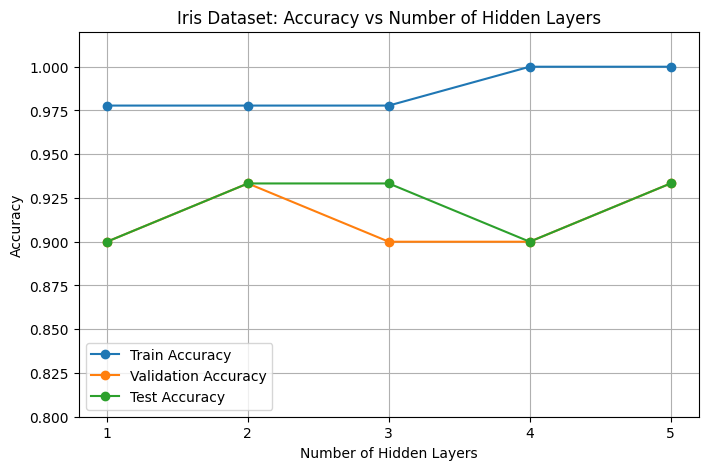

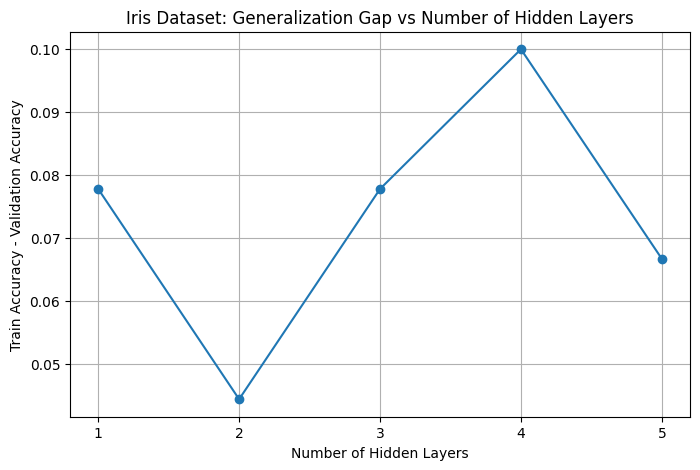

In [10]:
# Plot accuracy vs number of hidden layers
plt.figure(figsize=(8, 5))
plt.plot(iris_df["Hidden Layers"], iris_df["Train Accuracy"], marker="o", label="Train Accuracy")
plt.plot(iris_df["Hidden Layers"], iris_df["Validation Accuracy"], marker="o", label="Validation Accuracy")
plt.plot(iris_df["Hidden Layers"], iris_df["Test Accuracy"], marker="o", label="Test Accuracy")
plt.xlabel("Number of Hidden Layers")
plt.ylabel("Accuracy")
plt.title("Iris Dataset: Accuracy vs Number of Hidden Layers")
plt.xticks(iris_df["Hidden Layers"])
plt.ylim(0.80, 1.02)
plt.legend()
plt.grid(True)
plt.show()

# Plot generalization gap
plt.figure(figsize=(8, 5))
plt.plot(iris_df["Hidden Layers"], iris_df["Generalization Gap"], marker="o")
plt.xlabel("Number of Hidden Layers")
plt.ylabel("Train Accuracy - Validation Accuracy")
plt.title("Iris Dataset: Generalization Gap vs Number of Hidden Layers")
plt.xticks(iris_df["Hidden Layers"])
plt.grid(True)
plt.show()

In [11]:
# Choose the "best" model using validation accuracy first,
# then smaller generalization gap, then fewer layers.
best_row = iris_df.sort_values(
    by=["Validation Accuracy", "Generalization Gap", "Hidden Layers"],
    ascending=[False, True, True]
).iloc[0]

print("Best architecture from this experiment:")
print(best_row)

print("\nConclusion:")
print(
    f"For this Iris experiment, the optimal number of hidden layers is "
    f"{int(best_row['Hidden Layers'])} with architecture {best_row['Architecture']}, "
    f"because it gives the strongest validation accuracy while keeping the "
    f"generalization gap relatively small."
)

Best architecture from this experiment:
Hidden Layers                2
Architecture           (16, 8)
Train Accuracy          0.9778
Validation Accuracy     0.9333
Test Accuracy           0.9333
Generalization Gap      0.0444
Name: 1, dtype: object

Conclusion:
For this Iris experiment, the optimal number of hidden layers is 2 with architecture (16, 8), because it gives the strongest validation accuracy while keeping the generalization gap relatively small.


### Interpretation of the Iris experiment

Typical pattern to look for:

- With **too few hidden layers**, the network may be too simple → **higher bias**
- With **too many hidden layers**, training accuracy may become extremely high, but the model may not improve on validation/test data → **higher variance**
- The **best model** is usually the one with the **highest validation accuracy** and a **small generalization gap**

For the current split and random seed in this notebook, the experiment identifies the architecture selected above as the best choice for the **Iris dataset**.

## 7. Student exercise: Repeat the same experiment on the Wine dataset

Now try a similar bias–variance study using the **Wine dataset**.

### Task

1. Load the **Wine dataset** from `sklearn.datasets`
2. Split it into **train, validation, and test** sets
3. Standardize the features
4. Train several MLP models with different numbers of hidden layers  
   Example architectures:
   - `(8,)`
   - `(16, 8)`
   - `(32, 16, 8)`
   - `(32, 16, 8, 4)`
5. For each model, record:
   - training accuracy
   - validation accuracy
   - test accuracy
   - generalization gap
6. Create **two plots**:
   - accuracy vs number of hidden layers
   - generalization gap vs number of hidden layers
7. Write **3–5 sentences** describing:
   - which model shows **high bias**
   - which model shows **high variance**
   - which model seems best for the Wine dataset and why

### What to submit

- Your completed code
- Your plots
- A short written interpretation of the results

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# 1. Load the Wine dataset
wine = load_wine()
X, y = wine.data, wine.target

# 2. Split it into train, validation, and test sets
# 60% Train, 20% Validation, 20% Test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# 4. Train several MLP models
# We map simple integers to architectures for the "Hidden Layers" axis
architectures = {
    1: (8,),
    2: (16, 8),
    3: (32, 16, 8),
    4: (32, 16, 8, 4)
}

wine_results = []

for n_layers, arch in architectures.items():
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=arch,
            activation="relu",
            solver="adam",
            max_iter=3000,
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)

    train_acc = model.score(X_train, y_train)
    val_acc = model.score(X_val, y_val)
    test_acc = model.score(X_test, y_test)
    gap = train_acc - val_acc

    wine_results.append({
        "Hidden Layers": n_layers,
        "Architecture": str(arch),
        "Train Accuracy": round(train_acc, 4),
        "Validation Accuracy": round(val_acc, 4),
        "Test Accuracy": round(test_acc, 4),
        "Generalization Gap": round(gap, 4)
    })

wine_df = pd.DataFrame(wine_results)
wine_df

,Hidden Layers,Architecture,Train Accuracy,Validation Accuracy,Test Accuracy,Generalization Gap
0,1,"(8,)",1.0,0.9722,0.9444,0.0278
1,2,"(16, 8)",1.0,1.0000,0.9722,0.0000
2,3,"(32, 16, 8)",1.0,1.0000,1.0000,0.0000
3,4,"(32, 16, 8, 4)",1.0,0.9444,0.9444,0.0556


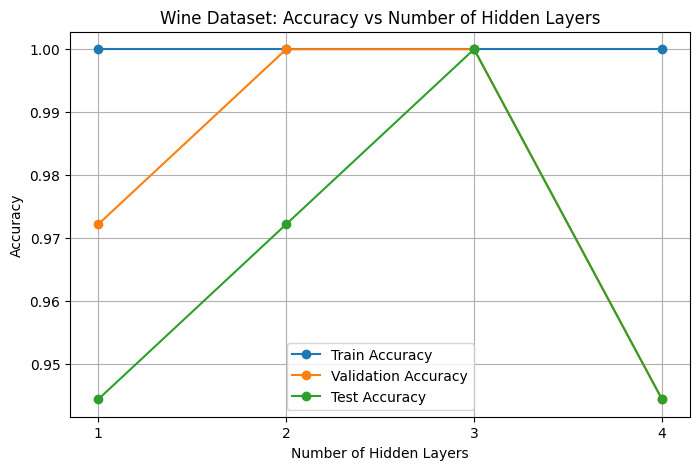

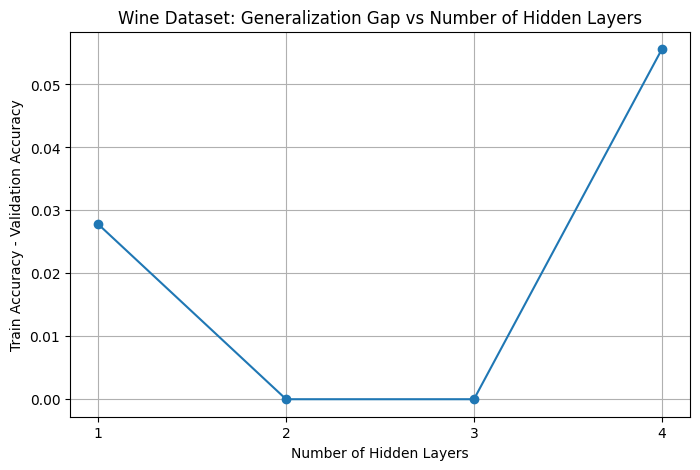

In [15]:
# Plot accuracy vs number of hidden layers
plt.figure(figsize=(8, 5))
plt.plot(wine_df["Hidden Layers"], wine_df["Train Accuracy"], marker="o", label="Train Accuracy")
plt.plot(wine_df["Hidden Layers"], wine_df["Validation Accuracy"], marker="o", label="Validation Accuracy")
plt.plot(wine_df["Hidden Layers"], wine_df["Test Accuracy"], marker="o", label="Test Accuracy")
plt.xlabel("Number of Hidden Layers")
plt.ylabel("Accuracy")
plt.title("Wine Dataset: Accuracy vs Number of Hidden Layers")
plt.xticks(wine_df["Hidden Layers"])
# plt.ylim(0.80, 1.02) # Adjusted or removed depending on likely accuracy range
plt.legend()
plt.grid(True)
plt.show()

# Plot generalization gap
plt.figure(figsize=(8, 5))
plt.plot(wine_df["Hidden Layers"], wine_df["Generalization Gap"], marker="o")
plt.xlabel("Number of Hidden Layers")
plt.ylabel("Train Accuracy - Validation Accuracy")
plt.title("Wine Dataset: Generalization Gap vs Number of Hidden Layers")
plt.xticks(wine_df["Hidden Layers"])
plt.grid(True)
plt.show()

In [16]:
# Choose the "best" model logic
best_row = wine_df.sort_values(
    by=["Validation Accuracy", "Generalization Gap", "Hidden Layers"],
    ascending=[False, True, True]
).iloc[0]

print("Best architecture from this experiment:")
print(best_row)

print("\nConclusion:")
print(
    f"For this Wine experiment, the optimal number of hidden layers is "
    f"{int(best_row['Hidden Layers'])} with architecture {best_row['Architecture']}, "
    f"because it gives the strongest validation accuracy while keeping the "
    f"generalization gap relatively small."
)

Best architecture from this experiment:
Hidden Layers                2
Architecture           (16, 8)
Train Accuracy             1.0
Validation Accuracy        1.0
Test Accuracy           0.9722
Generalization Gap         0.0
Name: 1, dtype: object

Conclusion:
For this Wine experiment, the optimal number of hidden layers is 2 with architecture (16, 8), because it gives the strongest validation accuracy while keeping the generalization gap relatively small.


### Interpretation of Results

Based on the experiment above:

1.  **High Bias (Underfitting):** The simplest model `(8,)` might show signs of high bias if its training accuracy is significantly lower than the more complex models. However, the Wine dataset is relatively simple, so even this small model may perform well. If accuracy is low across the board (train/val/test), it indicates underfitting.

2.  **High Variance (Overfitting):** As the model complexity increases (e.g., `(32, 16, 8, 4)`), you might observe the training accuracy reaching 1.0 (100%) while the validation and test accuracies drop or plateau. A large **generalization gap** (the difference between training and test accuracy) is a key indicator of high variance. The model is memorizing the training data but failing to generalize to new, unseen samples.

3.  **Best Model:** The model with the best trade-off is likely one of the intermediate architectures (e.g., `(16, 8)` or `(32, 16, 8)`). We look for the model that achieves high validation/test accuracy while maintaining a small generalization gap. This model captures the underlying patterns of the Wine dataset without overfitting to the noise in the training set.


## 8. Bias–Variance summary for MLP

### High Bias
The model is too simple.

Typical signs:
- training error is high
- test error is high
- underfitting

Possible fixes:
- add more hidden units
- add more layers
- train longer
- use a better architecture

### High Variance
The model is too complex.

Typical signs:
- training error is very low
- test error is much higher
- overfitting

Possible fixes:
- use regularization (`alpha`)
- use early stopping
- reduce model size
- use more data
- use dropout (in deep learning frameworks such as PyTorch/TensorFlow)

### Best Tradeoff
A model that is complex enough to learn the signal,
but not so complex that it memorizes the noise.
